# Student Academic Risk: Data Preparation


## 1. Imports and  load dataset


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

folder = next(Path("/kaggle/input").rglob("studentInfo.csv")).parent
print("Dataset folder:", folder)

# Treat ? as a missing value
student_info = pd.read_csv(folder / "studentInfo.csv", na_values=["?"])
registration = pd.read_csv(folder / "studentRegistration.csv", na_values=["?"])
student_assessment = pd.read_csv(folder / "studentAssessment.csv", na_values=["?"])
assessments = pd.read_csv(folder / "assessments.csv", na_values=["?"])
student_vle = pd.read_csv(folder / "studentVle.csv", na_values=["?"])
vle = pd.read_csv(folder / "vle.csv", na_values=["?"])
courses = pd.read_csv(folder / "courses.csv", na_values=["?"])

Dataset folder: /kaggle/input/datasets/abhijithms1825/outlad


## 2. Data Inspection and Quality Assessment


In [31]:
files = {
    "studentInfo": student_info,
    "studentRegistration": registration,
    "studentAssessment": student_assessment,
    "assessments": assessments,
    "studentVle": student_vle,
    "vle": vle,
    "courses": courses
}

for name, df in files.items():
    print("\nFILE:", name)
    print("Shape:", df.shape)

    df.info()

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    display(df.head())
    display(df.describe(include="all"))


FILE: studentInfo
Shape: (32593, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB

Missing values:
code_module                0
code_presentation          0
id_student                 0

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
count,32593,32593,3.259300e+04,32593,32593,32593,31482,32593,32593.000000,32593.000000,32593,32593
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN



FILE: studentRegistration
Shape: (32593, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB

Missing values:
code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64

Duplicate rows: 0


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


...

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


,id_site,code_module,code_presentation,activity_type,week_from,week_to
count,6.364000e+03,6364,6364,6364,1121.000000,1121.000000
unique,NaN,7,4,20,NaN,NaN
top,NaN,FFF,2013J,resource,NaN,NaN
freq,NaN,1967,1772,2660,NaN,NaN
mean,7.260991e+05,NaN,NaN,NaN,15.204282,15.214987
std,1.283151e+05,NaN,NaN,NaN,8.792865,8.779806
min,5.267210e+05,NaN,NaN,NaN,0.000000,0.000000
25%,6.615928e+05,NaN,NaN,NaN,8.000000,8.000000
50%,7.300965e+05,NaN,NaN,NaN,15.000000,15.000000
75%,8.140162e+05,NaN,NaN,NaN,22.000000,22.000000



FILE: courses
Shape: (22, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   code_module                 22 non-null     object
 1   code_presentation           22 non-null     object
 2   module_presentation_length  22 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 660.0+ bytes

Missing values:
code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

Duplicate rows: 0


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


,code_module,code_presentation,module_presentation_length
count,22,22,22.000000
unique,7,4,NaN
top,BBB,2014J,NaN
freq,4,7,NaN
mean,NaN,NaN,255.545455
std,NaN,NaN,13.654677
min,NaN,NaN,234.000000
25%,NaN,NaN,241.000000
50%,NaN,NaN,261.500000
75%,NaN,NaN,268.000000


## 3. Data Cleaning and Standardisation

In [32]:
student_info = student_info.drop_duplicates().copy()
registration = registration.drop_duplicates().copy()
student_assessment = student_assessment.drop_duplicates().copy()
assessments = assessments.drop_duplicates().copy()
vle = vle.drop_duplicates().copy()
courses = courses.drop_duplicates().copy()

# Clean the deprivation band
student_info["imd_band"] = (
    student_info["imd_band"]
    .replace({"10-20": "10-20%"})
    .fillna("Unknown")
)

# Ensure numeric columns have numeric types
student_assessment["score"] = pd.to_numeric(
    student_assessment["score"], errors="coerce"
)

assessments["date"] = pd.to_numeric(
    assessments["date"], errors="coerce"
)

for col in ["date_registration", "date_unregistration"]:
    registration[col] = pd.to_numeric(
        registration[col], errors="coerce"
    )

for col in ["week_from", "week_to"]:
    vle[col] = pd.to_numeric(vle[col], errors="coerce")

print(student_info["imd_band"].value_counts())

imd_band
20-30%     3654
30-40%     3539
10-20%     3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Unknown    1111
Name: count, dtype: int64


## 4. Student Engagement Metrics

Summarises each student’s recorded VLE activity within a module and presentation, calculating total clicks, active days, resources accessed, and average clicks per active day.

In [33]:
# Identify each student within a specific module and presentation
keys = ["code_module", "code_presentation", "id_student"]

# Create a table containing student engagement metrics
engagement = (
    # Group activity records by module, presentation, and student
    student_vle.groupby(keys)

    # Calculate summary metrics for each group
    .agg(
        # Add all recorded clicks
        total_clicks=("sum_click", "sum"),

        # Count distinct days with recorded activity
        active_days=("date", "nunique"),

        # Count distinct learning resources accessed
        resources_accessed=("id_site", "nunique")
    )

    # Convert the grouping columns into regular DataFrame columns
    .reset_index()
)

# Calculate average clicks per active day, rounded to two decimal places
engagement["clicks_per_active_day"] = (
    engagement["total_clicks"] / engagement["active_days"]
).round(2)

# Display the first five rows of the engagement summary
display(engagement.head())

,code_module,code_presentation,id_student,total_clicks,active_days,resources_accessed,clicks_per_active_day
0,AAA,2013J,11391,934,40,55,23.35
1,AAA,2013J,28400,1435,80,84,17.94
2,AAA,2013J,30268,281,12,22,23.42
3,AAA,2013J,31604,2158,123,82,17.54
4,AAA,2013J,32885,1034,70,66,14.77


The resulting table contains one row per student, module, and presentation, allowing engagement metrics to be merged with student information without repeating individual activity records.

 ## 5. Student Assessment Summary

Combine student assessment records with assessment details to identify
the module and presentation associated with each score.

For each student within a module and presentation, calculate:
- **Average Score:** Simple mean of available assessment scores.
- **Assessments Recorded:** Number of distinct assessments with a student record.
- **Assessments Scored:** Number of records with a non-missing score.

Missing scores are excluded from the average. The average score is
unweighted and does not represent an official final grade.

In [34]:
assessment_details = student_assessment.merge(
    assessments,
    on="id_assessment",
    how="left",
    validate="many_to_one"
)

grade_summary = (
    assessment_details.groupby(keys)
    .agg(
        average_score=("score", "mean"),
        assessments_recorded=("id_assessment", "nunique"),
        assessments_scored=("score", "count")
    )
    .reset_index()
)

grade_summary["average_score"] = (
    grade_summary["average_score"].round(2)
)

display(grade_summary.head())

,code_module,code_presentation,id_student,average_score,assessments_recorded,assessments_scored
0,AAA,2013J,11391,82.0,5,5
1,AAA,2013J,28400,66.4,5,5
2,AAA,2013J,31604,76.0,5,5
3,AAA,2013J,32885,54.4,5,5
4,AAA,2013J,38053,68.0,5,5


## 6. Student Dataset Integration

Combine student information, registration details, course details,
engagement metrics, and assessment summaries into one dataset.

Each row represents one student within a module and presentation.
Left joins retain all records from the student information table.

Missing activity and assessment counts are filled with zero.
Average scores and clicks per active day remain missing when
there is insufficient information to calculate them.

In [35]:
merged = student_info.merge(
    registration,
    on=keys,
    how="left",
    validate="one_to_one"
)

merged = merged.merge(
    courses,
    on=["code_module", "code_presentation"],
    how="left",
    validate="many_to_one"
)

merged = merged.merge(
    engagement,
    on=keys,
    how="left",
    validate="one_to_one"
)

merged = merged.merge(
    grade_summary,
    on=keys,
    how="left",
    validate="one_to_one"
)

# No recorded activity or assessments: count = 0
count_columns = [
    "total_clicks",
    "active_days",
    "resources_accessed",
    "assessments_recorded",
    "assessments_scored"
]

merged[count_columns] = (
    merged[count_columns].fillna(0).astype("int64")
)

# Keep average_score missing where no scores are available.
# Keep clicks_per_active_day missing where no active days exist.

print("Final shape:", merged.shape)
print("Duplicate student-course rows:", merged.duplicated(keys).sum())

assert len(merged) == len(student_info)

display(merged.head())

Final shape: (32593, 22)
Duplicate student-course rows: 0


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,date_unregistration,module_presentation_length,total_clicks,active_days,resources_accessed,clicks_per_active_day,average_score,assessments_recorded,assessments_scored
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,-159.0,NaN,268,934,40,55,23.35,82.0,5,5
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,-53.0,NaN,268,1435,80,84,17.94,66.4,5,5
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,-92.0,12.0,268,281,12,22,23.42,NaN,0,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,-52.0,NaN,268,2158,123,82,17.54,76.0,5,5
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,-176.0,NaN,268,1034,70,66,14.77,54.4,5,5


In [36]:
summary = pd.Series({
    "Student-course enrolments": len(merged),
    "Unique students": merged["id_student"].nunique(),
    "Modules": merged["code_module"].nunique(),
    "Average assessment score": merged["average_score"].mean().round(2),
    "Median total clicks": merged["total_clicks"].median()
})

display(summary.to_frame("Value"))

,Value
Student-course enrolments,32593.00
Unique students,28785.00
Modules,7.00
Average assessment score,72.77
Median total clicks,602.00


In [37]:
merged.to_csv(
    "/kaggle/working/cleaned_student_data.csv",
    index=False
)

# **Grade distribution Charts**

In [38]:
import seaborn as sns

# Set a consistent appearance for all charts
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 16
})

# Keep the result categories in the same order
order = ["Distinction", "Pass", "Fail", "Withdrawn"]

# Use consistent colours across charts
colors = {
    "Distinction": "#10B981",
    "Pass": "#3B82F6",
    "Fail": "#EF4444",
    "Withdrawn": "#F59E0B"
}

**Student Final Result Distribution**

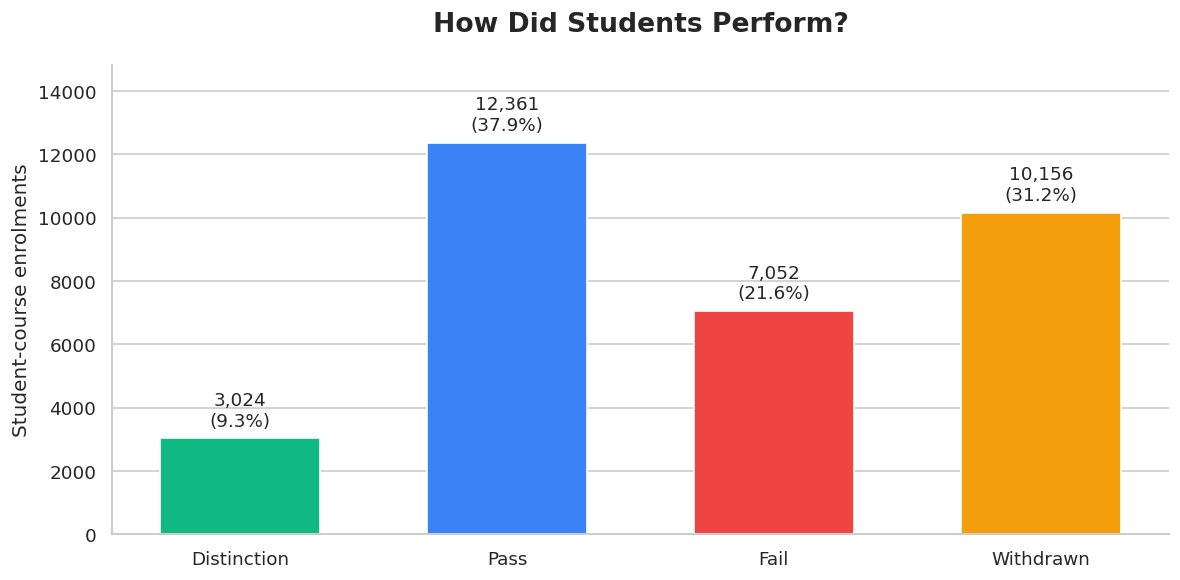

In [39]:
counts = merged["final_result"].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots()

bars = ax.bar(
    counts.index,
    counts.values,
    color=[colors[result] for result in order],
    width=0.6
)

labels = [
    f"{count:,}\n({count / len(merged):.1%})"
    for count in counts
]

ax.bar_label(bars, labels=labels, padding=5, fontsize=11)

ax.set_title("How Did Students Perform?", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Student-course enrolments")
ax.set_ylim(0, counts.max() * 1.2)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("/kaggle/working/final_result_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

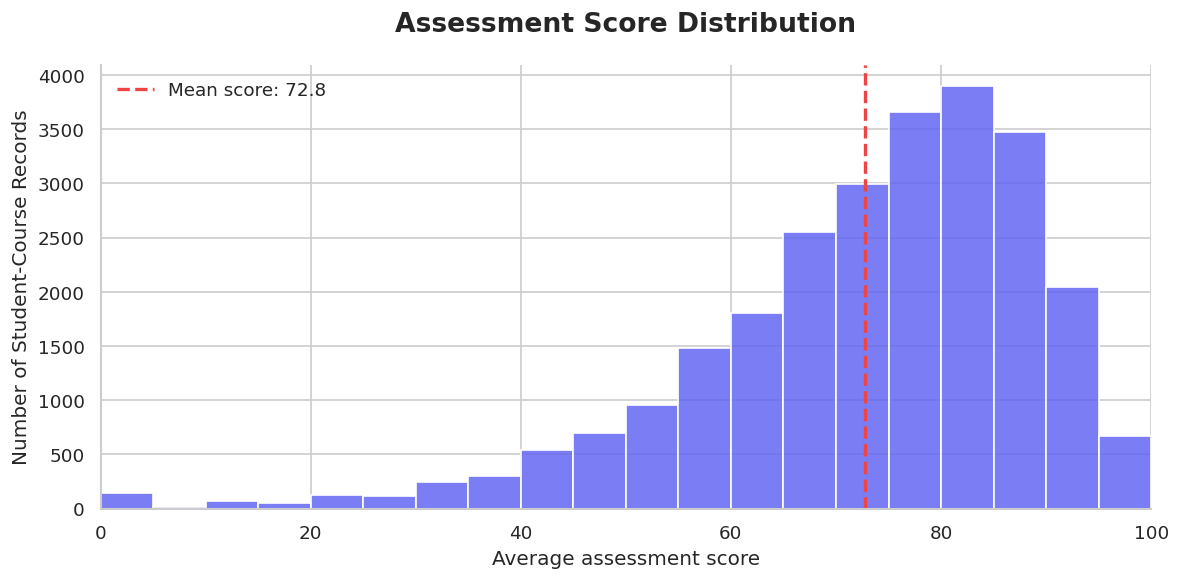

In [40]:
scores = merged["average_score"].dropna()
mean_score = scores.mean()

fig, ax = plt.subplots()

sns.histplot(
    scores,
    bins=20,
    binrange=(0, 100),
    color="#6366F1",
    edgecolor="white",
    alpha=0.85,
    ax=ax
)

ax.axvline(
    mean_score,
    color="#EF4444",
    linestyle="--",
    linewidth=2,
    label=f"Mean score: {mean_score:.1f}"
)

ax.set_title("Assessment Score Distribution", pad=20)
ax.set_xlabel("Average assessment score")
ax.set_ylabel("Number of Student-Course Records")
ax.set_xlim(0, 100)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("/kaggle/working/assessment_score_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

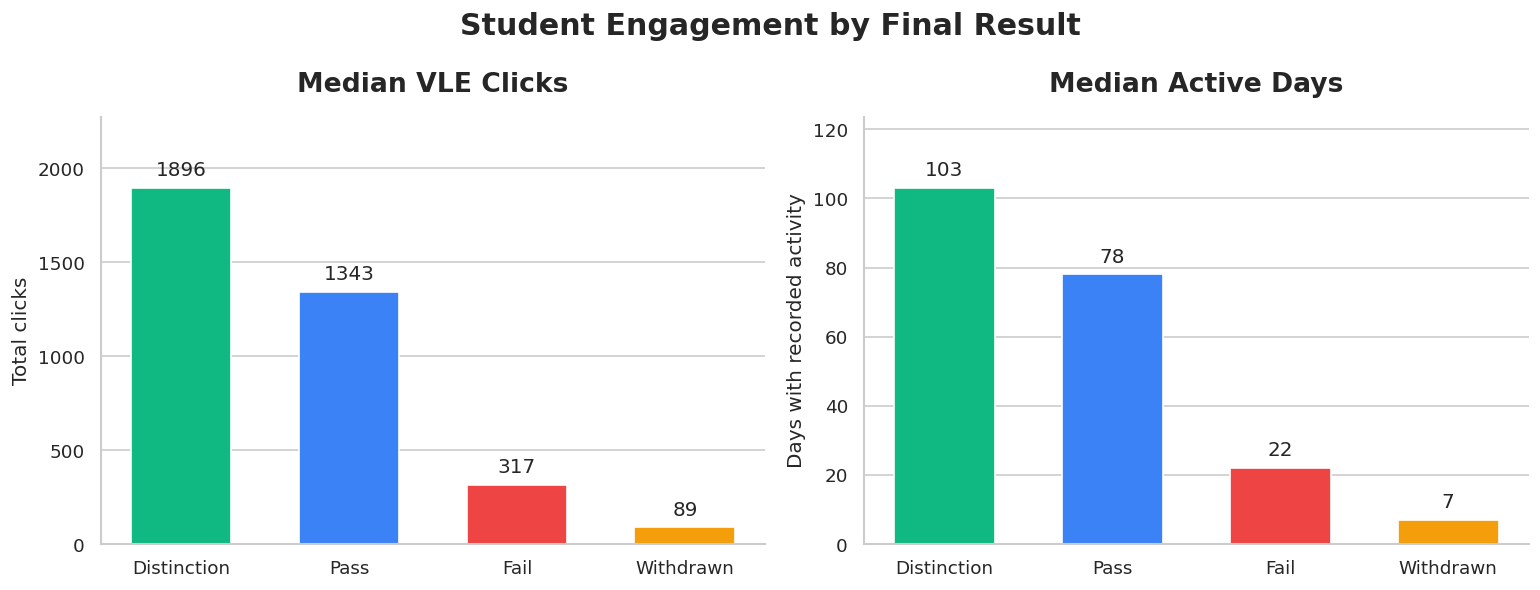

In [41]:
engagement_summary = (
    merged.groupby("final_result")[["total_clicks", "active_days"]]
    .median()
    .reindex(order)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, column, title, ylabel in zip(
    axes,
    ["total_clicks", "active_days"],
    ["Median VLE Clicks", "Median Active Days"],
    ["Total clicks", "Days with recorded activity"]
):
    bars = ax.bar(
        order,
        engagement_summary[column],
        color=[colors[result] for result in order],
        width=0.6
    )

    ax.bar_label(bars, fmt="%.0f", padding=5)
    ax.set_title(title, pad=15)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, engagement_summary[column].max() * 1.2)
    ax.grid(axis="x", visible=False)

fig.suptitle("Student Engagement by Final Result", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/engagement_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()

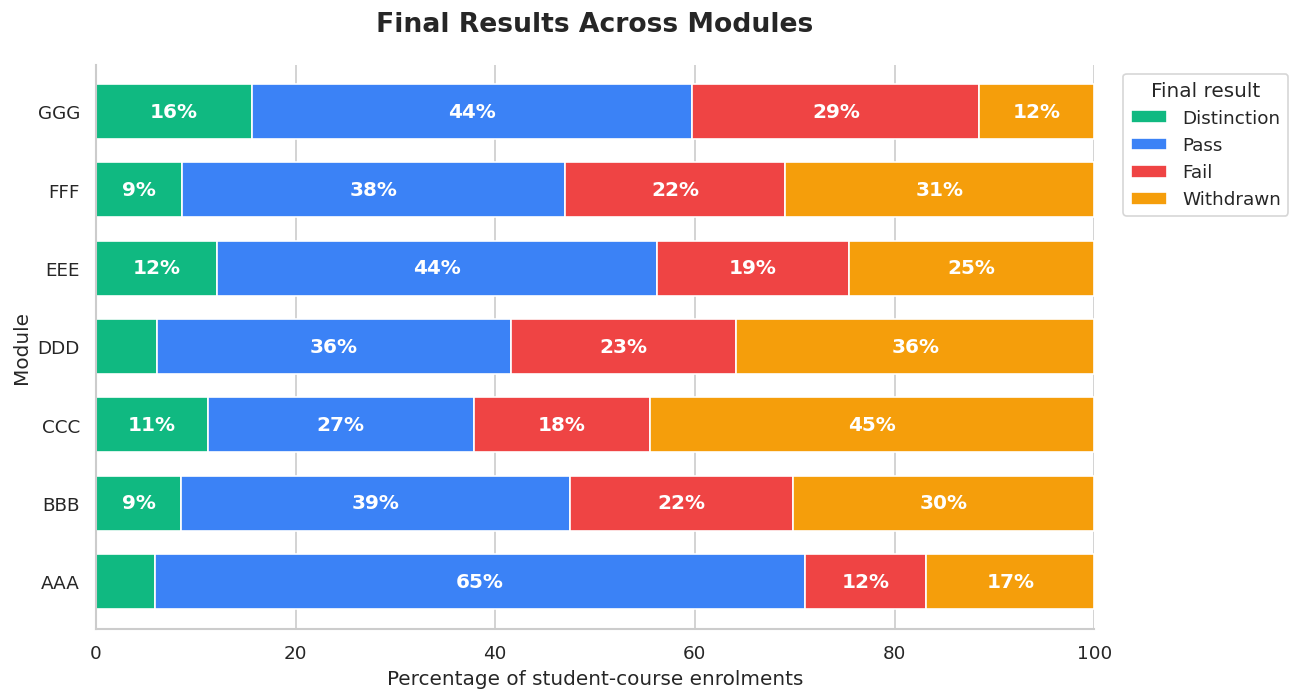

In [42]:
module_results = pd.crosstab(
    merged["code_module"],
    merged["final_result"],
    normalize="index"
).mul(100).reindex(columns=order, fill_value=0)

ax = module_results.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 6),
    color=[colors[result] for result in order],
    width=0.7
)

for container in ax.containers:
    labels = [
        f"{value:.0f}%" if value >= 7 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type="center",
                 color="white", fontweight="bold")

ax.set_title("Final Results Across Modules", pad=20)
ax.set_xlabel("Percentage of student-course enrolments")
ax.set_ylabel("Module")
ax.set_xlim(0, 100)
ax.legend(title="Final result", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("/kaggle/working/module_performance.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [44]:
df=pd.read_csv("/kaggle/working/cleaned_student_data.csv")

In [46]:
df.isna().sum()

code_module                       0
code_presentation                 0
id_student                        0
gender                            0
region                            0
highest_education                 0
imd_band                          0
age_band                          0
num_of_prev_attempts              0
studied_credits                   0
disability                        0
final_result                      0
date_registration                45
date_unregistration           22521
module_presentation_length        0
total_clicks                      0
active_days                       0
resources_accessed                0
clicks_per_active_day          3365
average_score                  6773
assessments_recorded              0
assessments_scored                0
dtype: int64

| Column | Missing | Meaning and treatment |
|---|---:|---|
| `date_registration` | 45 | Registration date is unavailable. Keep missing. |
| `date_unregistration` | 22,521 | No unregistration date is recorded. Keep missing; zero would mean unregistration on day 0. |
| `clicks_per_active_day` | 3,365 | No recorded active days, so clicks per active day cannot be calculated. Keep missing. |
| `average_score` | 6,773 | No available assessment scores for these enrolments. Keep missing; zero would incorrectly represent a score of 0. |

### Remaining Missing Values

Missing values are retained where information is unavailable or a metric
cannot be calculated. Missing dates are not replaced with artificial
values. Enrolments without recorded activity have no clicks-per-active-day
value, while enrolments without available scores have no average score.
Count columns use zero to indicate no recorded activity or assessments.